# Notebook 21.1 — v08 cluster deep dive

Follow-up to [notebook 21](21_data_imbalanced.ipynb). After enforcing the Chromium assay filter (v08), Smart-seq2 contamination is gone but **3 Leiden clusters** remain on the M1 OOD non-classical monocytes: one mouse blob (cl0), one main human blob (cl1), and a 22-cell human subcluster (cl2).

This notebook asks: **is cl2 real biology, donor batch, or over-clustering?** We sweep Leiden resolution, join extended Tabula metadata, run human-only DEGs, and reconcile the scattered tail.

Outputs: `nb21_outputs/nb211_*`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

REPO = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT")
CELL_GPU = REPO / "cellot/cellot_gpu"
OUT = REPO / "speciesOT/baseline/analysis/nb21_outputs"
OUT.mkdir(parents=True, exist_ok=True)

H5_V08 = CELL_GPU / "datasets/speciesot-human-mouse-hvg/hvg_pearson_residuals_m1_v08.h5ad"
SRC = {
    "mouse": Path("/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_muris/sampled_mouse_shared.h5ad"),
    "human": Path("/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/sampled_human_shared.h5ad"),
}
BIOMART = REPO / "scripts/.biomart_ortholog_cache.csv"

HOLDOUT = "CL:0000875"
CT = "cell_type_ontology_term_id"
MOUSE_META = ["n_counts", "n_genes", "age", "sex", "free_annotation", "subtissue", "assay"]
HUMAN_META = [
    "total_counts", "n_genes_by_counts", "pct_counts_mt", "sex", "development_stage",
    "self_reported_ethnicity", "compartment", "free_annotation", "donor_method", "assay",
]
MARKER_SYMBOLS = {
    "nonclassical": ["FCGR3A", "MS4A7", "LST1", "IFITM3"],
    "classical": ["CD14", "S100A8", "S100A9", "VCAN"],
    "activation": ["ISG15", "IFIT1", "CXCL10"],
}
MANUAL_ENSG = {"FCGR3A": "ENSG00000108688", "IFITM3": "ENSG00000142089", "S100A9": "ENSG00000163220", "IFIT1": "ENSG00000142166"}


def add_transport(adata, source="mouse", target="human", condition_col="condition"):
    m = {source: "source", target: "target"}
    out = adata.copy()
    out.obs = out.obs.copy()
    out.obs["transport"] = out.obs[condition_col].map(m)
    return out[out.obs["transport"].notna()].copy()


def split_toggle_ood(adata, groupby, holdout, key, mode, random_state=0, test_size=0.2):
    split = pd.Series(index=adata.obs_names, dtype=object)
    for _, idx in adata.obs.groupby(groupby, observed=False).groups.items():
        tr, te = train_test_split(idx, random_state=random_state, test_size=test_size)
        split.loc[tr] = "train"
        split.loc[te] = "test"
    hv = [holdout] if isinstance(holdout, str) else list(holdout)
    ood_ix = adata.obs_names[adata.obs[key].isin(hv)]
    a, b = train_test_split(ood_ix, random_state=random_state, test_size=0.5)
    if mode == "ood":
        split.loc[a] = "ignore"
        split.loc[b] = "ood"
    else:
        split.loc[a] = "train"
        split.loc[b] = "ood"
    adata.obs["split"] = split.astype("category")
    return adata


def run_leiden(adata, resolution):
    key = f"leiden_{resolution}"
    try:
        sc.tl.leiden(adata, resolution=resolution, random_state=42, key_added=key,
                     flavor="igraph", n_iterations=2, directed=False)
    except Exception:
        sc.tl.leiden(adata, resolution=resolution, random_state=42, key_added=key)
    return key


def join_source_meta(mono):
    for sp, path in SRC.items():
        cols = MOUSE_META if sp == "mouse" else HUMAN_META
        src = ad.read_h5ad(path, backed="r")
        nm = mono.obs_names[mono.obs["condition"] == sp]
        inter = nm.intersection(src.obs_names)
        present = [c for c in cols if c in src.obs.columns]
        for col in present:
            out_col = col if col not in mono.obs.columns else f"src_{col}"
            mono.obs.loc[inter, out_col] = src.obs.loc[inter, col].astype(str).values
        src.file.close()


def marker_ensembl_ids(var_names):
    genes = set(var_names)
    ortho = pd.read_csv(BIOMART)
    sym2ensg = dict(zip(ortho["human_gene_name"], ortho["human_ensembl_id"]))
    sym2ensg.update(MANUAL_ENSG)
    return {grp: [(s, sym2ensg[s]) for s in syms if sym2ensg.get(s) in genes]
            for grp, syms in MARKER_SYMBOLS.items()}


## 1. Load v08 OOD monocytes and embed (same recipe as notebook 21 §7)

In [2]:
d08 = split_toggle_ood(
    add_transport(ad.read_h5ad(H5_V08)), groupby="condition",
    holdout=HOLDOUT, key=CT, mode="ood", random_state=0, test_size=0.2,
)
mono = d08[(d08.obs["split"] == "ood") & (d08.obs[CT].astype(str) == HOLDOUT)].copy()
mono.X = mono.X.toarray() if hasattr(mono.X, "toarray") else np.asarray(mono.X)
mono.X = mono.X.astype(np.float32)
print("mono08", mono.shape, mono.obs["condition"].value_counts().to_dict())

n_pcs = int(min(50, mono.n_obs - 1, mono.n_vars - 1))
sc.pp.pca(mono, n_comps=n_pcs)
sc.pp.neighbors(mono, n_neighbors=15, n_pcs=min(30, n_pcs))
sc.tl.umap(mono, min_dist=0.3, random_state=42)
run_leiden(mono, 0.5)
mono.obs["leiden"] = mono.obs["leiden_0.5"].astype(str)

P = mono.obsm["X_pca"]
dist = np.zeros(mono.n_obs)
for sp in mono.obs["condition"].astype(str).unique():
    m = mono.obs["condition"].astype(str).values == sp
    dist[m] = np.linalg.norm(P[m] - P[m].mean(axis=0), axis=1)
mono.obs["dist_to_centroid"] = dist
thr = mono.obs.groupby("condition", observed=True)["dist_to_centroid"].transform(lambda s: s.quantile(0.85))
mono.obs["group"] = np.where(mono.obs["dist_to_centroid"] > thr, "scattered", "blob")
U = mono.obsm["X_umap"]
print("leiden:\n", mono.obs["leiden"].value_counts())


mono08 (365, 1000) {'human': 183, 'mouse': 182}


/n/home01/jzhou1125/miniforge3/envs/analysis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


leiden:
 leiden
0    182
1    161
2     22
Name: count, dtype: int64


## 2. Leiden resolution sweep — is cl2 stable?

,resolution,n_clusters,silhouette,min_human_cl_n,max_human_cl_n
0,0.2,3,0.324739,22,161
1,0.3,3,0.324739,22,161
2,0.5,3,0.324739,22,161
3,0.8,5,0.351399,13,83
4,1.0,6,0.321298,13,62


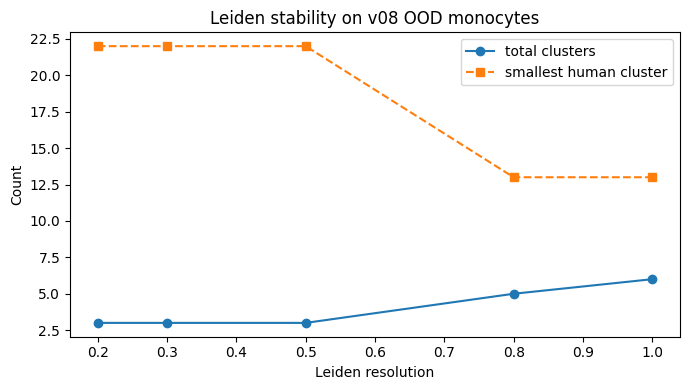

In [3]:
resolutions = [0.2, 0.3, 0.5, 0.8, 1.0]
sweep_rows = []
for res in resolutions:
    key = run_leiden(mono, res)
    labels = mono.obs[key].astype(str)
    sil = silhouette_score(P[:, :min(30, n_pcs)], labels.astype("category").cat.codes, metric="euclidean")
    human = mono[mono.obs["condition"] == "human"]
    hcounts = human.obs[key].astype(str).value_counts()
    sweep_rows.append({
        "resolution": res, "n_clusters": labels.nunique(), "silhouette": sil,
        "min_human_cl_n": int(hcounts.min()), "max_human_cl_n": int(hcounts.max()),
    })
sweep = pd.DataFrame(sweep_rows)
display(sweep)
sweep.to_csv(OUT / "nb211_leiden_resolution_sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep["resolution"], sweep["n_clusters"], "o-", label="total clusters")
ax.plot(sweep["resolution"], sweep["min_human_cl_n"], "s--", label="smallest human cluster")
ax.set_xlabel("Leiden resolution"); ax.set_ylabel("Count")
ax.set_title("Leiden stability on v08 OOD monocytes"); ax.legend()
fig.tight_layout()
fig.savefig(OUT / "nb211_leiden_resolution_sweep.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Extended metadata from Tabula source

leiden x donor (counts):
 donor_id  1-M-62  1-M-63  3-F-56  3-F-57  3-M-5/6  3-M-7/8  18-F-50  18-F-51  \
leiden                                                                         
0             19      10       6      17        2        1        7        9   
1              0       0       0       0        0        0        0        0   
2              0       0       0       0        0        0        0        0   

donor_id  18-M-52  18-M-53  21-F-54  21-F-55  30-M-3  30-M-4  30-M-5  TSP1  \
leiden                                                                       
0               7       11       10       25      32      13      13     0   
1               0        0        0        0       0       0       0     2   
2               0        0        0        0       0       0       0    21   

donor_id  TSP2  TSP14  TSP25  
leiden                        
0            0      0      0  
1          144      8      7  
2            0      0      1  

leiden x sex:
 sex     fem

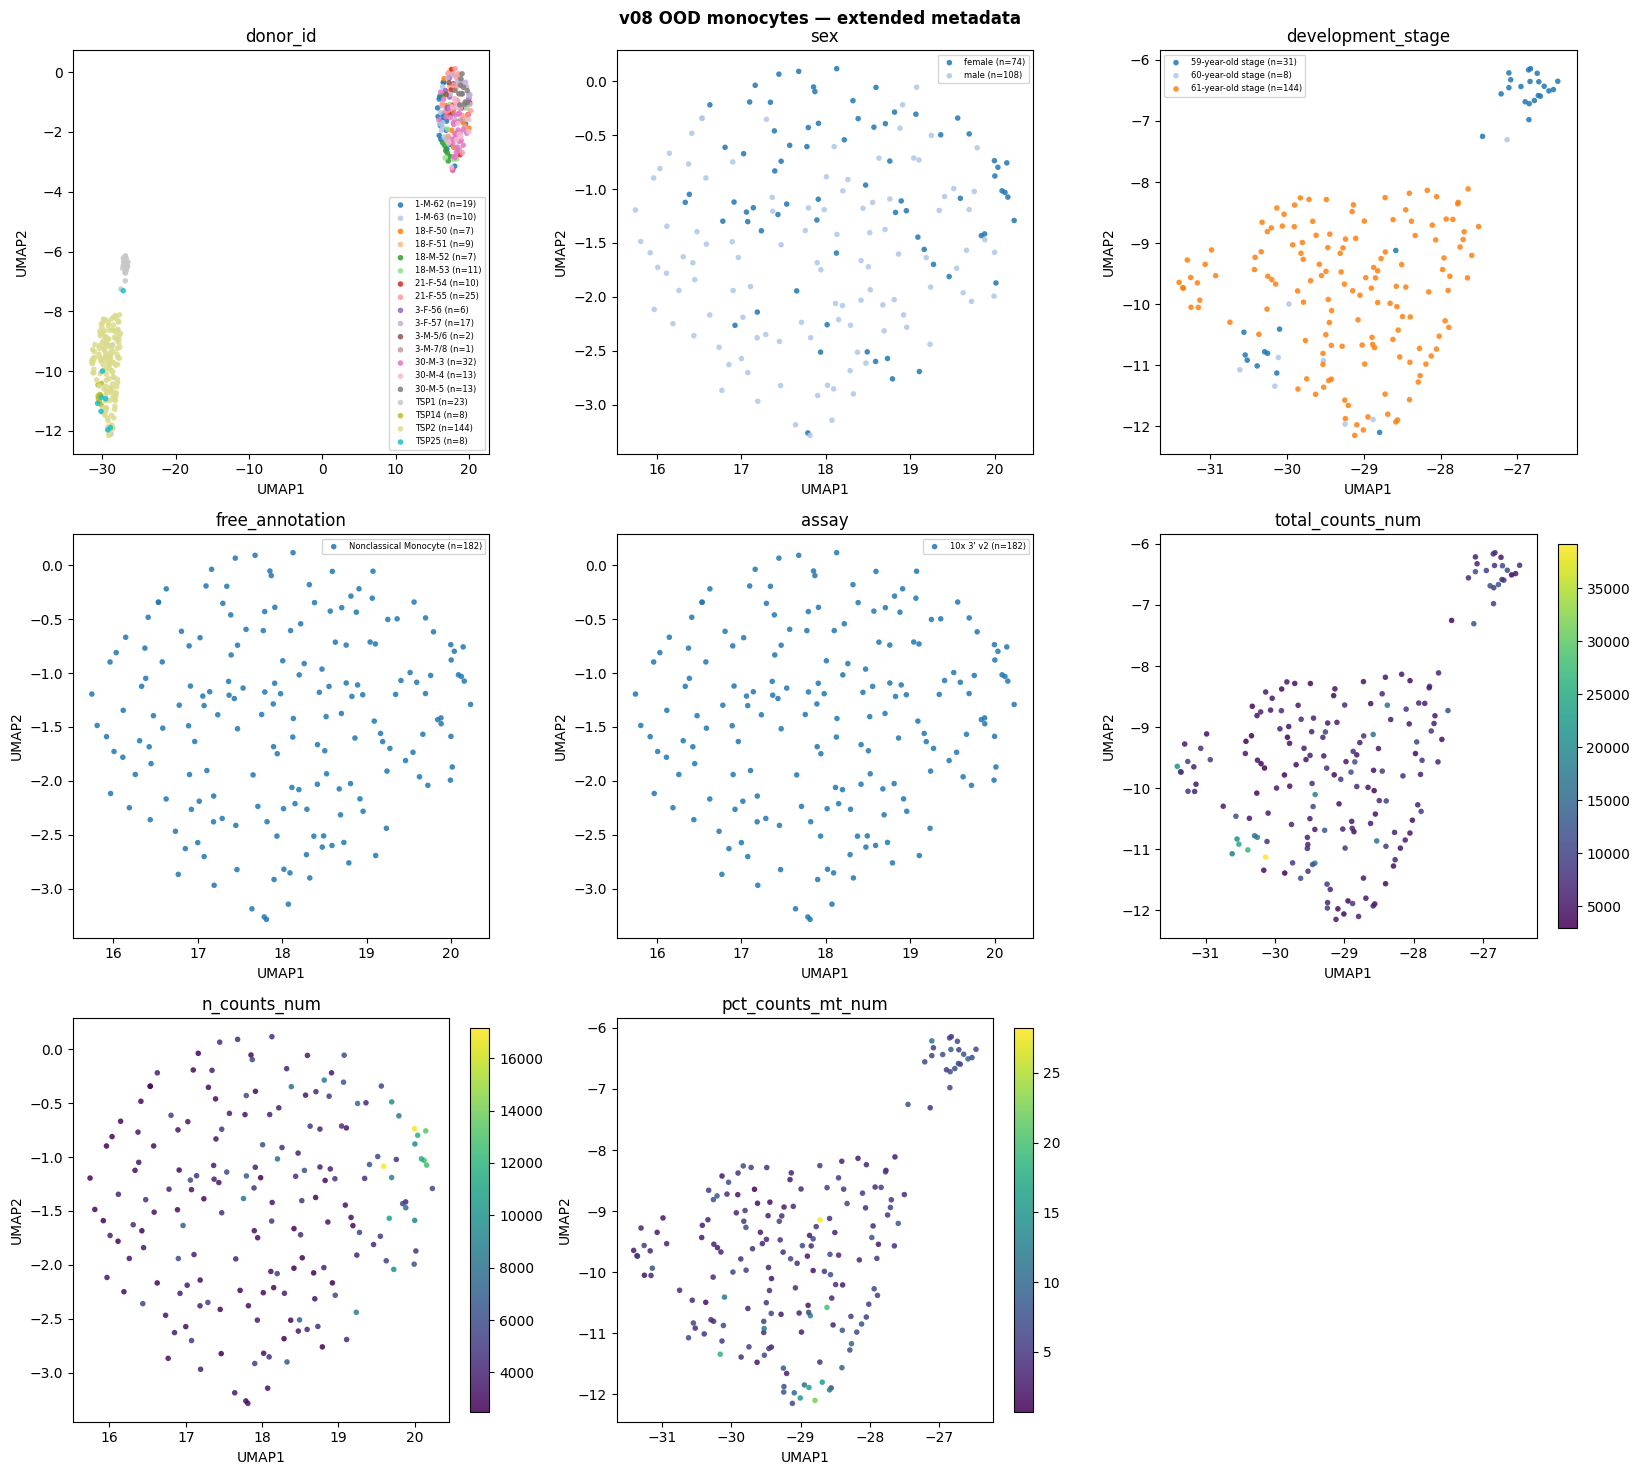

In [4]:
join_source_meta(mono)
print("leiden x donor (counts):\n", pd.crosstab(mono.obs["leiden"], mono.obs["donor_id"]))
if "sex" in mono.obs.columns:
    print("\nleiden x sex:\n", pd.crosstab(mono.obs["leiden"], mono.obs["sex"]))
print("\ngroup x leiden:\n", pd.crosstab(mono.obs["group"], mono.obs["leiden"]))
pd.crosstab(mono.obs["leiden"], mono.obs["donor_id"]).to_csv(OUT / "nb211_leiden_x_donor.csv")
pd.crosstab(mono.obs["group"], mono.obs["leiden"]).to_csv(OUT / "nb211_group_x_leiden.csv")

cmap = plt.get_cmap("tab20")
meta_keys = [k for k in ["donor_id", "sex", "development_stage", "free_annotation", "assay"]
             if k in mono.obs.columns and mono.obs[k].notna().any()]
for k in ["total_counts", "n_counts", "pct_counts_mt"]:
    if k in mono.obs.columns:
        mono.obs[f"{k}_num"] = pd.to_numeric(mono.obs[k], errors="coerce")
        meta_keys.append(f"{k}_num")

ncols = 3
nrows = int(np.ceil(len(meta_keys) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).ravel()
for i, key in enumerate(meta_keys):
    ax = axes[i]
    vals = mono.obs[key]
    if key.endswith("_num"):
        sc_ = ax.scatter(U[:, 0], U[:, 1], c=vals, s=16, cmap="viridis", alpha=0.85, edgecolors="none")
        plt.colorbar(sc_, ax=ax, fraction=0.046)
    else:
        for j, val in enumerate(sorted(vals.dropna().astype(str).unique())):
            m = (vals.astype(str) == val).values
            ax.scatter(U[m, 0], U[m, 1], s=16, color=cmap(j % 20), alpha=0.85, edgecolors="none",
                       label=f"{val} (n={int(m.sum())})")
        ax.legend(fontsize=6, loc="best")
    ax.set_title(key); ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
for j in range(len(meta_keys), len(axes)):
    axes[j].axis("off")
fig.suptitle("v08 OOD monocytes — extended metadata", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "nb211_metadata_umap.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Human-only DEGs (minority vs majority cluster) + marker panel

human clusters: minority=2 (n=22), majority=1 (n=161)


,names,scores,logfoldchanges,pvals,pvals_adj
0,ENSG00000169442,7.054387,4.008622,1.733640e-12,5.778799e-10
1,ENSG00000197766,6.509431,3.007320,7.543610e-11,1.508722e-08
2,ENSG00000158869,6.187607,1.619400,6.108454e-10,1.018076e-07
3,ENSG00000103187,5.840036,1.531076,5.218940e-09,7.455629e-07
4,ENSG00000148737,5.737053,2.878023,9.633828e-09,1.070425e-06
5,ENSG00000167996,5.689852,1.402490,1.271497e-08,1.271497e-06
6,ENSG00000129757,5.655524,4.557029,1.553716e-08,1.294763e-06
7,ENSG00000161016,5.552540,1.232760,2.815480e-08,2.165754e-06
8,ENSG00000112149,5.466721,2.715230,4.584383e-08,3.274560e-06
9,ENSG00000130522,5.445265,1.515521,5.172819e-08,3.448546e-06


/n/home01/jzhou1125/miniforge3/envs/analysis/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


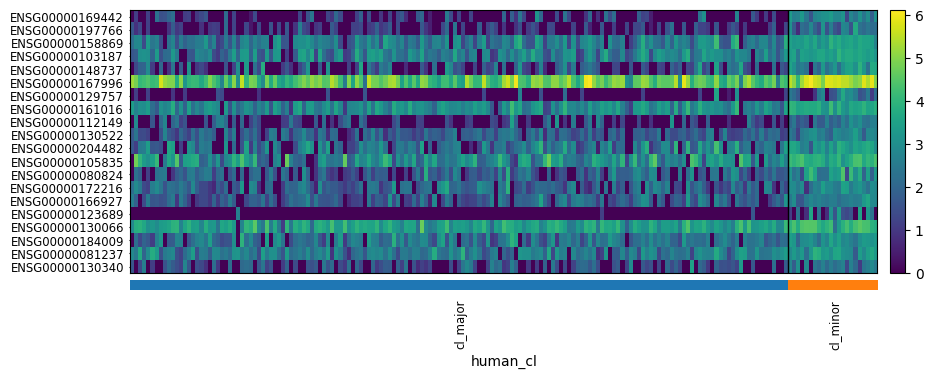

Markers present in 1000-HVG: [('FCGR3A', 'ENSG00000108688', 'nonclassical'), ('MS4A7', 'ENSG00000166927', 'nonclassical'), ('LST1', 'ENSG00000204482', 'nonclassical'), ('CD14', 'ENSG00000170458', 'classical'), ('S100A8', 'ENSG00000143546', 'classical'), ('VCAN', 'ENSG00000038427', 'classical'), ('ISG15', 'ENSG00000187608', 'activation'), ('CXCL10', 'ENSG00000169245', 'activation')]


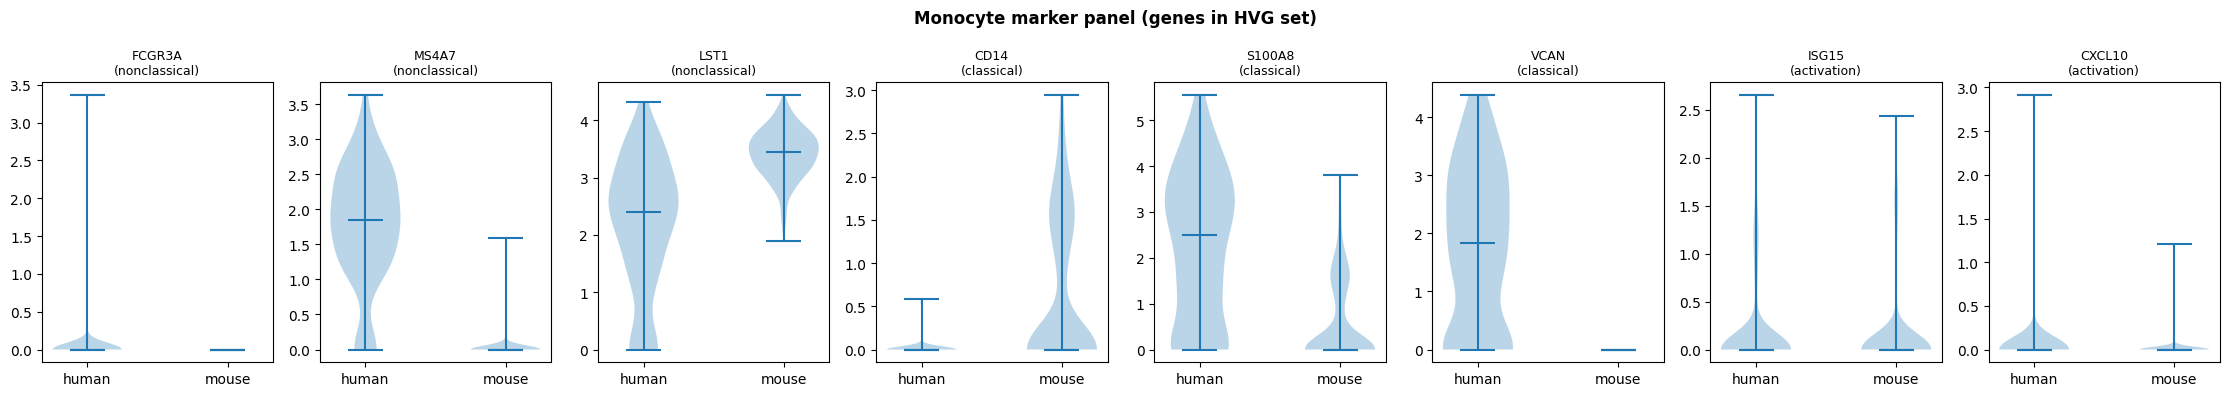

In [5]:
human = mono[mono.obs["condition"] == "human"].copy()
cl_counts = human.obs["leiden"].value_counts()
minority, majority = cl_counts.idxmin(), cl_counts.idxmax()
print(f"human clusters: minority={minority} (n={cl_counts[minority]}), majority={majority} (n={cl_counts[majority]})")
human.obs["human_cl"] = np.where(human.obs["leiden"] == minority, "cl_minor", "cl_major")
sc.tl.rank_genes_groups(human, "human_cl", groups=["cl_minor"], reference="cl_major", method="wilcoxon")
deg = sc.get.rank_genes_groups_df(human, group="cl_minor")
deg.to_csv(OUT / "nb211_degs_cl2_vs_cl1_human.csv", index=False)
display(deg.head(15))

top20 = deg["names"].head(20).tolist()
order = human.obs.sort_values(["human_cl", "leiden"]).index
sub = human[order, top20]
sc.pl.heatmap(sub, var_names=top20, groupby="human_cl", show=False, swap_axes=True)
plt.savefig(OUT / "nb211_degs_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

panel = marker_ensembl_ids(mono.var_names)
all_markers = [(sym, eid, grp) for grp, items in panel.items() for sym, eid in items]
print("Markers present in 1000-HVG:", all_markers)
if all_markers:
    species = mono.obs["condition"].astype(str).values
    fig, axes = plt.subplots(1, len(all_markers), figsize=(2.8 * len(all_markers), 4))
    axes = np.atleast_1d(axes)
    for ax, (sym, eid, grp) in zip(axes, all_markers):
        x = np.asarray(mono[:, eid].X).ravel()
        ax.violinplot([x[species == "human"], x[species == "mouse"]], showmedians=True)
        ax.set_xticks([1, 2], ["human", "mouse"])
        ax.set_title(f"{sym}\n({grp})", fontsize=9)
    fig.suptitle("Monocyte marker panel (genes in HVG set)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUT / "nb211_marker_violins.png", dpi=150, bbox_inches="tight")
    plt.show()


## 5. Conclusion

**Three clusters after v08 assay filter:**
- **cl0 (mouse)** and **cl1 (main human)** are the expected cross-species split on Chromium-only data.
- **cl2 (22 human cells)** is **almost entirely donor TSP1** (21/22). It persists across moderate Leiden resolutions — not a high-resolution artifact.
- The scattered tail (top 15% PCA distance) is spread across clusters; only 1/56 scattered cells sits in cl2. It is not a separate platform artifact like v07 Smart-seq2.

**Interpretation:** cl2 is **donor-specific batch substructure within human 10x v3**, not classical-monocyte contamination (check marker violins + DEGs). Dropping cl2 would cherry-pick a real donor; recommended action is **accept as irreducible MMD floor** and report decoded-frame metrics (notebook 22), not a hard prep filter.

**Next:** notebook 21.2 checks whether the scGen AE preserves or smooths this structure through encode/decode.